In [1]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [13]:
# =============================================================================
# IMPORTS, PATHS, CONSTANTS
# =============================================================================

from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import json
import random
import time
import warnings
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from tqdm import tqdm

import torch
import gymnasium as gym
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

# =============================================================================
# EXPERIMENT SETTINGS
# =============================================================================

MASTER_SEED = 42

# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)
NUM_RUNS = 10

EPISODE_BUDGET = 1500

BASE_SEED_START = 5000

MAX_STEPS = 500

FAILURE_DELTA = 40.0

ACTION_SPACE = 2

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path(
    "/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study"
)

AGENT_ROOT = (
    ROOT
    / "agents"
    / "muzero"
    / "cartpole"
)

RESULTS_DIR = (
    ROOT
    / "results"
    / "cartpole"
)

RAW_DIR = RESULTS_DIR / "raw"
TABLES_DIR = RESULTS_DIR / "tables"
FIGS_DIR = RESULTS_DIR / "figs"

for p in [
    RESULTS_DIR,
    RAW_DIR,
    TABLES_DIR,
    FIGS_DIR,
]:
    p.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Device :", DEVICE)
print("Agent  :", AGENT_ROOT)
print("Results:", RESULTS_DIR)

Device : cuda
Agent  : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/agents/muzero/cartpole
Results: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/cartpole


In [14]:
# =============================================================================
# MUZERO AGENT LOADING
# =============================================================================
# =============================================================================
# LOAD MUZERO-GENERAL
# =============================================================================

import sys
import importlib
from pathlib import Path

LOCAL_MUZERO = Path("external/muzero-general")

if not LOCAL_MUZERO.exists():

    !git clone --depth=1 \
        https://github.com/werner-duvaud/muzero-general.git \
        external/muzero-general

if str(LOCAL_MUZERO) not in sys.path:
    sys.path.insert(0, str(LOCAL_MUZERO))

models = importlib.import_module("models")

from models import MuZeroNetwork

print(
    "✓ MuZero-General loaded from",
    LOCAL_MUZERO,
)
import models
from models import MuZeroNetwork

class CartPoleTrainingConfig:

    def __init__(self):

        self.observation_shape = (4, 1, 1)

        self.action_space = [0, 1]

        self.players = [0]

        self.stacked_observations = 0

        self.network = "fullyconnected"

        self.support_size = 10

        self.encoding_size = 32

        self.fc_representation_layers = [64, 64]

        self.fc_dynamics_layers = [64, 64]

        self.fc_reward_layers = [64]

        self.fc_value_layers = [64]

        self.fc_policy_layers = [64]

        self.train_on_gpu = False


cfg = CartPoleTrainingConfig()

checkpoint = torch.load(
    AGENT_ROOT / "model.checkpoint",
    map_location="cpu",
    weights_only=False,
)

NETWORK = MuZeroNetwork(cfg)

state = (
    checkpoint["weights"]
    if "weights" in checkpoint
    else checkpoint
)

NETWORK.load_state_dict(
    state,
    strict=False,
)

NETWORK.to(DEVICE)

NETWORK.eval()

print("✓ MuZero loaded")


# =============================================================================
# INFERENCE WRAPPERS
# =============================================================================

def _obs_to_tensor(obs):

    return torch.from_numpy(
        np.asarray(
            obs,
            dtype=np.float32,
        )
    ).reshape(
        1,
        4,
        1,
        1,
    ).to(DEVICE)


def initial_inference_fixed(obs):

    obs_t = _obs_to_tensor(obs)

    with torch.no_grad():

        value, reward, policy_logits, hidden = (
            NETWORK.initial_inference(obs_t)
        )

    probs = (
        torch.softmax(
            policy_logits,
            dim=1,
        )
        .cpu()
        .numpy()
        .flatten()
    )

    entropy = float(
        -np.sum(
            probs * np.log(
                probs + 1e-12
            )
        )
    )

    confidence = float(
        np.max(probs)
    )

    sorted_probs = np.sort(probs)

    margin = float(
        sorted_probs[-1]
        - sorted_probs[-2]
    )

    action = int(
        np.argmax(probs)
    )

    return (
        action,
        hidden,
        policy_logits,
        value,
        {
            "entropy": entropy,
            "confidence": confidence,
            "margin": margin,
        }
    )


def recurrent_inference_fixed(
    hidden,
    action,
):

    action_t = torch.tensor(
        [[int(action)]],
        dtype=torch.long,
        device=DEVICE,
    )

    with torch.no_grad():

        value, reward, policy_logits, hidden_next = (
            NETWORK.recurrent_inference(
                hidden,
                action_t,
            )
        )

    probs = (
        torch.softmax(
            policy_logits,
            dim=1,
        )
        .cpu()
        .numpy()
        .flatten()
    )

    entropy = float(
        -np.sum(
            probs * np.log(
                probs + 1e-12
            )
        )
    )

    confidence = float(
        np.max(probs)
    )

    sorted_probs = np.sort(probs)

    margin = float(
        sorted_probs[-1]
        - sorted_probs[-2]
    )

    action = int(
        np.argmax(probs)
    )

    return (
        action,
        hidden_next,
        policy_logits,
        value,
        {
            "entropy": entropy,
            "confidence": confidence,
            "margin": margin,
        }
    )


def CARTPOLE_POLICY(obs):

    action, _, _, _, _ = (
        initial_inference_fixed(obs)
    )

    return action

✓ MuZero-General loaded from external/muzero-general
✓ MuZero loaded


In [15]:
# =============================================================================
# ENVIRONMENT
# =============================================================================

def make_env(seed=None):

    env = gym.make("CartPole-v1")

    if seed is not None:
        env.reset(seed=int(seed))

    return env


def safe_reset(
    env,
    seed=None,
):

    out = (
        env.reset(seed=seed)
        if seed is not None
        else env.reset()
    )

    return out[0], {}


def safe_step(
    env,
    action,
):

    obs, reward, terminated, truncated, info = (
        env.step(int(action))
    )

    done = (
        terminated
        or truncated
    )

    return (
        np.asarray(
            obs,
            dtype=np.float32,
        ),
        float(reward),
        bool(done),
        info,
    )


# =============================================================================
# FAILURE ORACLE
# =============================================================================

def _calibrate(
    n=200,
    delta=FAILURE_DELTA,
):

    returns = []

    for i in range(n):

        env = make_env(
            MASTER_SEED + i
        )

        obs, _ = safe_reset(
            env,
            MASTER_SEED + i,
        )

        total = 0
        done = False
        steps = 0

        while (
            not done
            and steps < MAX_STEPS
        ):

            action = CARTPOLE_POLICY(
                obs
            )

            obs, reward, done, _ = (
                safe_step(
                    env,
                    action,
                )
            )

            total += reward
            steps += 1

        env.close()

        returns.append(total)

    mean_return = float(
        np.mean(returns)
    )

    return (
        mean_return
        - delta
    )


FAILURE_THRESHOLD = _calibrate()

print(
    "Failure threshold:",
    FAILURE_THRESHOLD,
)


def failure_oracle(
    total_return,
    steps,
    done,
):

    if (
        done
        and steps >= MAX_STEPS
    ):
        return 0

    if (
        done
        and total_return < FAILURE_THRESHOLD
    ):
        return 1

    return 0

Failure threshold: 338.92


In [16]:
# =============================================================================
# SIGNALS
# =============================================================================

def extract_latent_states(ep):

    return ep.get(
        "latent_history",
        [],
    )


def compute_latent_variance(
    latents,
):

    if len(latents) < 2:
        return 0.0

    H = np.stack(
        latents,
        axis=0,
    )

    return float(
        np.mean(
            np.var(
                H,
                axis=0,
            )
        )
    )


def compute_signals_for_pool(pool):

    for ep in pool:

        ep.setdefault(
            "latent_variance",
            compute_latent_variance(
                extract_latent_states(ep)
            ),
        )

        ep.setdefault(
            "entropy_mean",
            0.0,
        )

        ep.setdefault(
            "confidence_mean",
            1.0,
        )

        ep.setdefault(
            "margin_mean",
            1.0,
        )

        ep.setdefault(
            "value_return_gap",
            0.0,
        )

    return pool


# =============================================================================
# TCP METHODS
# =============================================================================

def tcp_fifo(pool):

    return sorted(
        pool,
        key=lambda x:
        x["episode_id"]
    )


def tcp_random(
    pool,
    seed=MASTER_SEED,
):

    rng = np.random.default_rng(seed)

    shuffled = pool.copy()

    rng.shuffle(shuffled)

    return shuffled


def tcp_entropy(pool):

    return sorted(
        pool,
        key=lambda x:
        x["entropy_mean"],
        reverse=True,
    )


def tcp_confidence(pool):

    return sorted(
        pool,
        key=lambda x:
        x["confidence_mean"],
    )


def tcp_policy_margin(pool):

    return sorted(
        pool,
        key=lambda x:
        x["margin_mean"],
    )


def tcp_value_return_gap(pool):

    return sorted(
        pool,
        key=lambda x:
        x["value_return_gap"],
        reverse=True,
    )


def tcp_latent_variance(pool):

    return sorted(
        pool,
        key=lambda x:
        x["latent_variance"],
        reverse=True,
    )


TCP_REGISTRY = {
    "FIFO": tcp_fifo,
    "Random": tcp_random,
    "Entropy": tcp_entropy,
    "Confidence": tcp_confidence,
    "PolicyMargin": tcp_policy_margin,
    "ValueReturnGap": tcp_value_return_gap,
    "LatentVariance": tcp_latent_variance,
}


# =============================================================================
# METRICS
# =============================================================================

def compute_metrics(
    results_df,
    tcp_time=0.0,
):

    failures = (
        results_df["failure"]
        .values
        .astype(int)
    )

    times = (
        results_df["time"]
        .values
        .astype(float)
    )

    n = len(failures)

    total_failures = int(
        np.sum(failures)
    )

    FR = (
        total_failures / n
        if n > 0 else np.nan
    )

    if total_failures > 0:

        first_idx = int(
            np.where(
                failures == 1
            )[0][0]
        )

        TTF_tests = (
            first_idx + 1
        )

        TTF_time = float(
            np.sum(
                times[
                    :first_idx+1
                ]
            )
        )

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures > 0:

        positions = (
            np.where(
                failures == 1
            )[0]
            + 1
        )

        APFD = float(
            1
            - (
                np.sum(
                    positions
                )
                /
                (
                    n
                    * total_failures
                )
            )
            + (
                1
                /
                (
                    2*n
                )
            )
        )

    else:

        APFD = np.nan

    if total_failures > 0:

        cumulative = np.cumsum(
            times
        )

        fail_times = cumulative[
            np.where(
                failures == 1
            )[0]
        ]

        total_time = cumulative[-1]

        APFD_time = float(
            1
            - (
                np.sum(
                    fail_times
                )
                /
                (
                    total_time
                    * total_failures
                )
            )
            + (
                1
                /
                (
                    2 * total_time
                )
            )
        )

    else:

        APFD_time = np.nan

    return {
        "FR": FR,
        "TTF_tests": TTF_tests,
        "TTF_time": TTF_time,
        "APFD": APFD,
        "APFD_time": APFD_time,
        "TCP_time": tcp_time,
        "Per_test_overhead":
            tcp_time / n,
    }

In [34]:
# =============================================================================
# PHASE 1 — TCP ONLY
# =============================================================================

def run_episode_full_mbrl(
    seed,
    test_case=None,
    p_random=0.0,
    obs_noise_std=0.0,
    rng_inject=None,
):

    rng = (
        rng_inject
        if rng_inject is not None
        else np.random.default_rng(seed)
    )

    env = make_env(seed)

    apply_cartpole_test_case(
        env,
        test_case,
    )

    obs, _ = safe_reset(
        env,
        seed=seed,
    )

    total_return = 0.0
    steps = 0
    done = False

    start = time.perf_counter()

    observation_history = []
    action_history = []
    reward_history = []

    latent_history = []

    entropy_history = []
    confidence_history = []
    margin_history = []

    value_history = []

    action, hidden, _, value, stats = (
        initial_inference_fixed(obs)
    )

    while (
        not done
        and steps < MAX_STEPS
    ):

        observation_history.append(
            np.asarray(obs).copy()
        )

        latent_history.append(
            hidden.detach()
            .cpu()
            .numpy()
            .flatten()
        )

        entropy_history.append(
            stats["entropy"]
        )

        confidence_history.append(
            stats["confidence"]
        )

        margin_history.append(
            stats["margin"]
        )

        value_history.append(
            float(
                value.detach()
                .cpu()
                .numpy()
                .mean()
            )
        )

        chosen_action = int(action)

        if (
            p_random > 0
            and rng.random() < p_random
        ):
            chosen_action = int(
                rng.integers(
                    0,
                    ACTION_SPACE,
                )
            )

        action_history.append(
            chosen_action
        )

        obs, reward, done, _ = (
            safe_step(
                env,
                chosen_action,
            )
        )

        if obs_noise_std > 0:

            obs = (
                obs
                + rng.normal(
                    0.0,
                    obs_noise_std,
                    size=obs.shape,
                )
            ).astype(np.float32)

        reward_history.append(
            float(reward)
        )

        total_return += reward

        steps += 1

        if done:
            break

        action, obs_hidden, _, value, stats = (
            initial_inference_fixed(obs)
        )

        hidden = obs_hidden

        env.close()

    latent_variance = compute_latent_variance(
        latent_history
    )

    entropy_mean = (
        float(np.mean(entropy_history))
        if entropy_history else 0.0
    )

    confidence_mean = (
        float(np.mean(confidence_history))
        if confidence_history else 1.0
    )

    margin_mean = (
        float(np.mean(margin_history))
        if margin_history else 1.0
    )

    value_mean = (
        float(np.mean(value_history))
        if value_history else 0.0
    )

    value_return_gap = float(
        abs(
            value_mean
            - total_return
        )
    )

    failure = failure_oracle(
        total_return,
        steps,
        done,
    )

    return {
        "seed": int(seed),

        "total_return":
            float(total_return),

        "steps":
            int(steps),

        "failure":
            int(failure),

        "wall_time":
            float(
                time.perf_counter()
                - start
            ),

        "latent_variance":
            latent_variance,

        "entropy_mean":
            entropy_mean,

        "confidence_mean":
            confidence_mean,

        "margin_mean":
            margin_mean,

        "value_mean":
            value_mean,

        "value_return_gap":
            value_return_gap,

        "observation_history":
            observation_history,

        "action_history":
            action_history,

        "reward_history":
            reward_history,

        "latent_history":
            latent_history,
    }


# =============================================================================
# GENERATE TEST POOL
# =============================================================================

def generate_test_pool(
    base_seed,
    budget=EPISODE_BUDGET,
):

    pool = []

    for episode_id in tqdm(
        range(budget),
        desc="Generating Pool",
        leave=False,
    ):

        seed = int(
            base_seed
            + episode_id
        )

        ep = run_episode_full_mbrl(
            seed=seed,
        )

        ep["episode_id"] = episode_id

        pool.append(ep)

    return pool


# =============================================================================
# APPLY TCP
# =============================================================================

def apply_tcp(
    pool,
    tcp_name,
    run_seed,
):

    func = TCP_REGISTRY[tcp_name]

    start = time.perf_counter()

    if tcp_name == "Random":

        ordered_pool = func(
            pool,
            seed=run_seed,
        )

    else:

        ordered_pool = func(pool)

    tcp_time = (
        time.perf_counter()
        - start
    )

    return ordered_pool, tcp_time


# =============================================================================
# TCP EVALUATION
# =============================================================================

def run_tcp_evaluation(
    ordered_pool,
    tcp_time,
):

    df = pd.DataFrame({
        "failure": [
            ep["failure"]
            for ep in ordered_pool
        ],
        "time": [
            ep["wall_time"]
            for ep in ordered_pool
        ],
    })

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return df, metrics


# =============================================================================
# PHASE 1
# =============================================================================

def run_phase1_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 1 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    pool = generate_test_pool(
        base_seed=base_seed,
        budget=EPISODE_BUDGET,
    )

    pool = compute_signals_for_pool(
        pool
    )

    rows = []

    for tcp_name in TCP_REGISTRY:

        ordered_pool, tcp_time = (
            apply_tcp(
                pool,
                tcp_name,
                base_seed,
            )
        )

        _, metrics = (
            run_tcp_evaluation(
                ordered_pool,
                tcp_time,
            )
        )

        row = {
            "run_id": run_id,
            "TCP": tcp_name,
        }

        row.update(metrics)

        rows.append(row)

        print(
            f"{tcp_name:<18}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase1_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(
        all_rows
    )

    results.to_csv(
        TABLES_DIR
        / "phase1_results.csv",
        index=False,
    )

    return results


def summarize_phase1(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby("TCP")[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(col)
        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR
        / "phase1_aggregate.csv",
        index=False,
    )

    return agg

In [35]:
def sample_cartpole_test_case(rng):
    return {
        "gravity": float(rng.uniform(8.8, 10.8)),
        "masscart": float(rng.uniform(0.9, 1.1)),
        "masspole": float(rng.uniform(0.08, 0.12)),
        "length": float(rng.uniform(0.45, 0.55)),
        "force_mag": float(rng.uniform(9.0, 11.0)),
        "init_noise": float(rng.uniform(0.00, 0.02)),
    }

def mutate_cartpole_test_case(
    parent: Dict[str, Any],
    rng: np.random.Generator,
    scale: float = 0.10,
) -> Dict[str, Any]:

    child = dict(parent)

    bounds = {
        "gravity": (7.0, 13.0),
        "masscart": (0.7, 1.3),
        "masspole": (0.05, 0.20),
        "length": (0.30, 0.80),
        "force_mag": (6.0, 14.0),
        "init_noise": (0.00, 0.08),
    }

    for k, (lo, hi) in bounds.items():
        width = hi - lo
        child[k] = float(np.clip(child[k] + rng.normal(0.0, scale * width), lo, hi))

    return child

def apply_cartpole_test_case(
    env,
    test_case=None,
):

    if test_case is None:
        return

    uenv = env.unwrapped

    for k in [
        "gravity",
        "masscart",
        "masspole",
        "length",
        "force_mag",
    ]:

        if k in test_case:

            setattr(
                uenv,
                k,
                float(test_case[k]),
            )

    if hasattr(uenv, "total_mass"):

        uenv.total_mass = (
            uenv.masspole
            + uenv.masscart
        )

    if hasattr(
        uenv,
        "polemass_length",
    ):

        uenv.polemass_length = (
            uenv.masspole
            * uenv.length
        )

# ==============================================================================
# FRAMEWORKs
# ==============================================================================
def _assign_episode_ids(pool: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    for i, ep in enumerate(pool):
        ep["episode_id"] = i
    return pool


def _episode_features(ep: Dict[str, Any]) -> List[float]:
    tc = ep.get("test_case", {})
    return [
        float(ep.get("steps", 0)),
        float(ep.get("total_return", 0.0)),
        float(ep.get("latent_variance", 0.0)),
        float(ep.get("entropy_mean", 0.0)),
        float(ep.get("confidence_mean", 1.0)),
        float(ep.get("margin_mean", 1.0)),
        float(tc.get("gravity", 9.8)),
        float(tc.get("masscart", 1.0)),
        float(tc.get("masspole", 0.1)),
        float(tc.get("length", 0.5)),
        float(tc.get("force_mag", 10.0)),
        float(tc.get("init_noise", 0.0)),
    ]


# ------------------------------------------------------------------------------
# Indago
# ------------------------------------------------------------------------------

def generate_pool_indago(base_seed, budget, pool_size=None):
    rng = np.random.default_rng(base_seed + 101)
    pool_size = pool_size or max(3 * budget, budget + 200)

    candidates = []

    for i in tqdm(range(pool_size), desc="Indago", leave=False):
        tc = sample_cartpole_test_case(rng)
        ep = run_episode_full_mbrl(
            seed=int(base_seed + i),
            test_case=tc,
            rng_inject=np.random.default_rng(base_seed + i),
        )
        candidates.append(ep)

    X = np.array([_episode_features(ep) for ep in candidates])
    y = np.array([ep["failure"] for ep in candidates])

    if len(np.unique(y)) < 2:
        selected = candidates[:budget]
        return _assign_episode_ids(selected)

    clf = RandomForestClassifier(
        n_estimators=150,
        random_state=base_seed,
        class_weight="balanced",
    )
    clf.fit(X, y)

    scored = []
    for ep in candidates:
        prob_fail = float(clf.predict_proba([_episode_features(ep)])[0][1])
        scored.append((prob_fail, ep))

    scored.sort(key=lambda x: x[0], reverse=True)
    selected = [ep for _, ep in scored[:budget]]

    return _assign_episode_ids(selected)


# ------------------------------------------------------------------------------
# STARLA
# ------------------------------------------------------------------------------

def generate_pool_starla(base_seed, budget):
    rng = np.random.default_rng(base_seed + 202)

    population_size = 60
    elite_size = 20

    population = [sample_cartpole_test_case(rng) for _ in range(population_size)]
    pool = []

    generation = 0

    while len(pool) < budget:
        evaluated = []

        for i, tc in enumerate(population):
            seed = int(base_seed + generation * 10000 + i)
            ep = run_episode_full_mbrl(seed=seed, test_case=tc, rng_inject=rng)

            fitness = (
                1000.0 * ep["failure"]
                + (MAX_STEPS - ep["steps"])
                + 10.0 * ep["latent_variance"]
                + 5.0 * ep["entropy_mean"]
            )

            evaluated.append((fitness, tc, ep))
            pool.append(ep)

            if len(pool) >= budget:
                break

        evaluated.sort(key=lambda x: x[0], reverse=True)
        elites = [tc for _, tc, _ in evaluated[:elite_size]]

        next_population = elites.copy()

        while len(next_population) < population_size:
            parent = elites[int(rng.integers(0, len(elites)))]
            child = mutate_cartpole_test_case(parent, rng, scale=0.05)
            next_population.append(child)

        population = next_population
        generation += 1

    return _assign_episode_ids(pool[:budget])


# ------------------------------------------------------------------------------
# QD-Testing
# ------------------------------------------------------------------------------

def generate_pool_qd(base_seed, budget=EPISODE_BUDGET):
    rng = np.random.default_rng(base_seed + 303)

    archive = {}
    attempts = 0
    max_attempts = max(8 * budget, 1000)

    while len(archive) < budget and attempts < max_attempts:
        tc = sample_cartpole_test_case(rng)
        ep = run_episode_full_mbrl(
            seed=int(base_seed + attempts),
            test_case=tc,
            rng_inject=rng,
        )

        bd = (
            int(ep["steps"] // 25),
            int(ep["total_return"] // 25),
            int(ep["latent_variance"] * 100),
        )

        quality = (
            1000.0 * ep["failure"]
            + 10.0 * ep["latent_variance"]
            + ep["entropy_mean"]
        )

        if bd not in archive or quality > archive[bd][0]:
            archive[bd] = (quality, ep)

        attempts += 1

    selected = [ep for _, ep in archive.values()]

    while len(selected) < budget:
        tc = sample_cartpole_test_case(rng)
        ep = run_episode_full_mbrl(
            seed=int(base_seed + attempts),
            test_case=tc,
            rng_inject=rng,
        )
        selected.append(ep)
        attempts += 1

    return _assign_episode_ids(selected[:budget])


# ------------------------------------------------------------------------------
# RLMutation
# ------------------------------------------------------------------------------

def generate_pool_rlmutation(base_seed, budget=EPISODE_BUDGET):
    rng = np.random.default_rng(base_seed + 404)
    pool = []

    mutation_rates = [0.00, 0.02, 0.05, 0.08]


    for ep_id in tqdm(range(budget), desc="RLMutation", leave=False):
        seed = int(base_seed + ep_id)
        p_mut = float(mutation_rates[ep_id % len(mutation_rates)])

        ep = run_episode_full_mbrl(
            seed=seed,
            test_case=None,
            p_random=p_mut,
            rng_inject=np.random.default_rng(seed + 999),
        )

        ep["mutation_rate"] = p_mut
        pool.append(ep)

    return _assign_episode_ids(pool)


# ------------------------------------------------------------------------------
# MDPFuzz
# ------------------------------------------------------------------------------

def generate_pool_mdpfuzz(base_seed, budget=EPISODE_BUDGET):
    rng = np.random.default_rng(base_seed + 505)

    corpus = [sample_cartpole_test_case(rng) for _ in range(20)]
    pool = []

    for i in tqdm(range(budget), desc="MDPFuzz", leave=False):
        parent = corpus[int(rng.integers(0, len(corpus)))]
        tc = mutate_cartpole_test_case(parent, rng, scale=0.15)

        ep = run_episode_full_mbrl(
            seed=int(base_seed + i),
            test_case=tc,
            rng_inject=rng,
        )

        pool.append(ep)
        is_failure = ep["failure"] == 1
        is_unstable = ep["latent_variance"] > np.percentile(
            [p.get("latent_variance", 0.0) for p in pool], 75
        ) if len(pool) > 10 else True

        if is_failure or is_unstable:
            corpus.append(tc)

        if len(corpus) > 200:
            corpus = corpus[-200:]

    return _assign_episode_ids(pool)


# ------------------------------------------------------------------------------
# NR-RL
# ------------------------------------------------------------------------------

def generate_pool_nrrl(base_seed, budget=EPISODE_BUDGET):
    rng = np.random.default_rng(base_seed + 606)
    pool = []

    noise_levels = [0.00, 0.005, 0.01, 0.015, 0.02]

    for i in tqdm(range(budget), desc="NR-RL", leave=False):
        noise_std = float(noise_levels[i % len(noise_levels)])

        ep = run_episode_full_mbrl(
            seed=int(base_seed + i),
            test_case=None,
            obs_noise_std=noise_std,
            rng_inject=np.random.default_rng(base_seed + i + 12345),
        )

        ep["obs_noise_std"] = noise_std
        pool.append(ep)

    return _assign_episode_ids(pool)

# ==============================================================================
# FRAMEWORK REGISTRY
# ==============================================================================

FRAMEWORK_REGISTRY = {
    "Indago": generate_pool_indago,
    "STARLA": generate_pool_starla,
    "QD-Testing": generate_pool_qd,
    "RLMutation": generate_pool_rlmutation,
    "MDPFuzz": generate_pool_mdpfuzz,
    "NR-RL": generate_pool_nrrl,
}

In [36]:
# =============================================================================
# PHASE 2 — FRAMEWORK-INTEGRATED TCP
# =============================================================================

def run_phase2_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 2 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    rows = []

    for framework_name, generator in FRAMEWORK_REGISTRY.items():

        print(
            f"\n[{framework_name}] Generating test pool..."
        )

        start = time.perf_counter()

        pool = generator(
            base_seed=base_seed,
            budget=EPISODE_BUDGET,
        )

        generation_time = (
            time.perf_counter()
            - start
        )

        pool = compute_signals_for_pool(
            pool
        )

        fr = np.mean(
            [ep["failure"] for ep in pool]
        )

        print(
            f"Generated {len(pool)} tests "
            f"(FR={fr:.3f})"
        )

        for tcp_name in TCP_REGISTRY:

            ordered_pool, tcp_time = apply_tcp(
                pool,
                tcp_name,
                run_seed=base_seed,
            )

            _, metrics = run_tcp_evaluation(
                ordered_pool,
                tcp_time,
            )

            row = {
                "run_id": run_id,
                "framework": framework_name,
                "tcp": tcp_name,
                "generation_time": generation_time,
            }

            row.update(metrics)

            rows.append(row)

            print(
                f"{tcp_name:<18}"
                f"APFD={metrics['APFD']:.4f}"
            )

    return rows


def run_phase2(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase2_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(
        all_rows
    )

    results.to_csv(
        TABLES_DIR / "phase2_results.csv",
        index=False,
    )

    return results


def summarize_phase2(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby(
            ["framework", "tcp"]
        )[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(col)
        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase2_aggregate.csv",
        index=False,
    )

    return agg

In [37]:
# =============================================================================
# STATISTICS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase1_statistics(results):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results["TCP"].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({
            "TCP": tcp,
            "p_value": p,
            "cliffs_delta":
                cliffs_delta(
                    vals,
                    fifo,
                ),
        })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase1_statistics.csv",
        index=False,
    )

    return stat_df


def phase2_statistics(results):

    rows = []

    for framework in results["framework"].unique():

        subset = results[
            results["framework"] == framework
        ]

        fifo = subset[
            subset["tcp"] == "FIFO"
        ]["APFD"].values

        for tcp in subset["tcp"].unique():

            if tcp == "FIFO":
                continue

            vals = subset[
                subset["tcp"] == tcp
            ]["APFD"].values

            if len(vals) < 2:
                continue

            _, p = mannwhitneyu(
                vals,
                fifo,
                alternative="two-sided",
            )

            rows.append({
                "framework": framework,
                "tcp": tcp,
                "p_value": p,
                "cliffs_delta":
                    cliffs_delta(
                        vals,
                        fifo,
                    ),
            })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase2_statistics.csv",
        index=False,
    )

    return stat_df

In [38]:
# =============================================================================
# ESSENTIAL PLOTS
# =============================================================================

TCP_COLOR_MAP = {
    "FIFO": "#4D4D4D",
    "Random": "#9E9E9E",
    "Entropy": "#1F77B4",
    "Confidence": "#2CA02C",
    "PolicyMargin": "#FF7F0E",
    "ValueReturnGap": "#9467BD",
    "LatentVariance": "#8C564B",
}

TCP_ORDER = [
    "FIFO",
    "Random",
    "Entropy",
    "Confidence",
    "PolicyMargin",
    "ValueReturnGap",
    "LatentVariance",
]


def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


def plot_phase1_apfd(agg):

    plt.figure(figsize=(6,3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP[t]
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")
    plt.title("CartPole Phase 1")

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    save_plot("phase1_apfd")

    plt.show()


def plot_phase2_apfd(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["APFD_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_apfd")

    plt.show()


def plot_phase2_overhead(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["TCP_time_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_overhead")

    plt.show()

CARTPOLE TCP REPLICATION

Running Phase 1...

Phase 1 | Run 1 (seed=5000)


FIFO              APFD=0.4650
Random            APFD=0.4870
Entropy           APFD=0.4065
Confidence        APFD=0.3175
PolicyMargin      APFD=0.3175
ValueReturnGap    APFD=0.1000
LatentVariance    APFD=0.7795

Running Phase 2...

Phase 2 | Run 1 (seed=5000)

[Indago] Generating test pool...


Generated 100 tests (FR=0.770)
FIFO              APFD=0.6150
Random            APFD=0.4828
Entropy           APFD=0.5315
Confidence        APFD=0.5285
PolicyMargin      APFD=0.5285
ValueReturnGap    APFD=0.3850
LatentVariance    APFD=0.5258

[STARLA] Generating test pool...
Generated 100 tests (FR=0.230)
FIFO              APFD=0.4459
Random            APFD=0.5220
Entropy           APFD=0.4393
Confidence        APFD=0.4002
PolicyMargin      APFD=0.4002
ValueReturnGap    APFD=0.1150
LatentVariance    APFD=0.7924

[QD-Testing] Generating test pool...
Generated 100 tests (FR=0.260)
FIFO              APFD=0.5665
Random            APFD=0.5754
Entropy           APFD=0.5562
Confidence        APFD=0.4592
PolicyMargin      APFD=0.4592
ValueReturnGap    APFD=0.1300
LatentVariance    APFD=0.7612

[RLMutation] Generating test pool...


Generated 100 tests (FR=0.320)
FIFO              APFD=0.4941
Random            APFD=0.4962
Entropy           APFD=0.3859
Confidence        APFD=0.3391
PolicyMargin      APFD=0.3391
ValueReturnGap    APFD=0.1600
LatentVariance    APFD=0.7847

[MDPFuzz] Generating test pool...


Generated 100 tests (FR=0.230)
FIFO              APFD=0.4902
Random            APFD=0.5354
Entropy           APFD=0.5389
Confidence        APFD=0.4563
PolicyMargin      APFD=0.4563
ValueReturnGap    APFD=0.1150
LatentVariance    APFD=0.8276

[NR-RL] Generating test pool...


Generated 100 tests (FR=0.480)
FIFO              APFD=0.5062
Random            APFD=0.5440
Entropy           APFD=0.3935
Confidence        APFD=0.3435
PolicyMargin      APFD=0.3435
ValueReturnGap    APFD=0.2400
LatentVariance    APFD=0.7129

Generating plots...


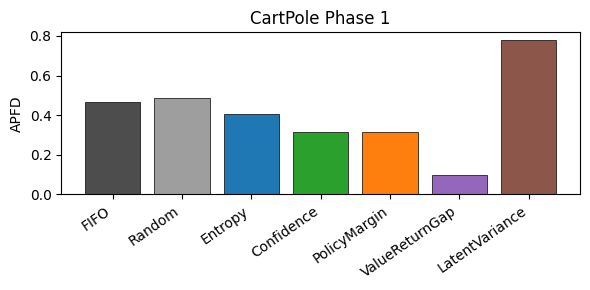

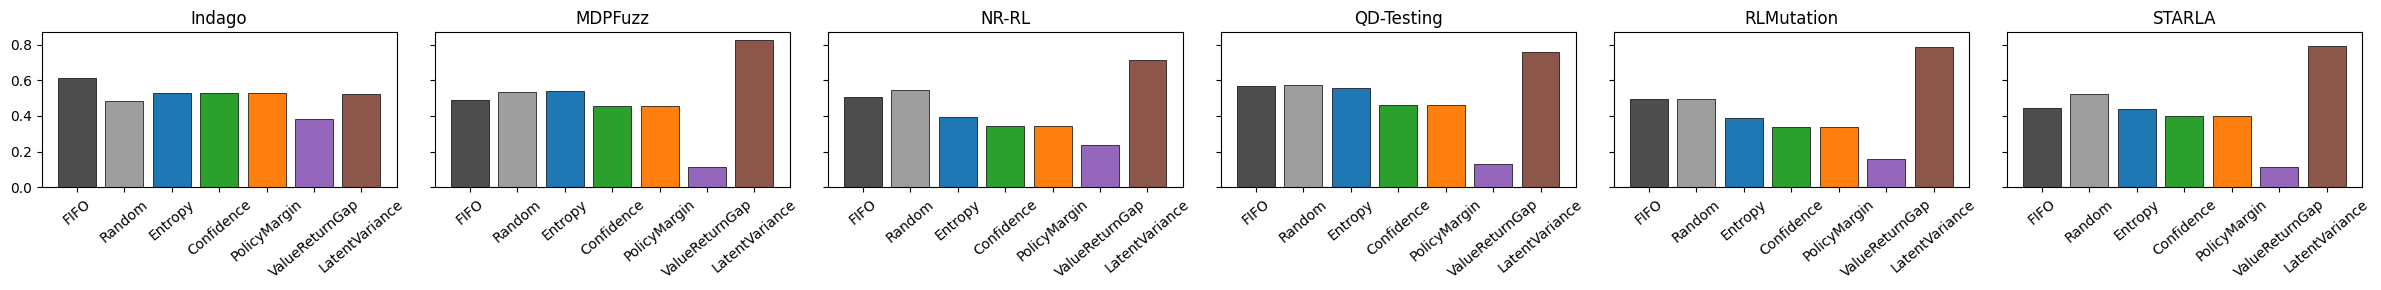

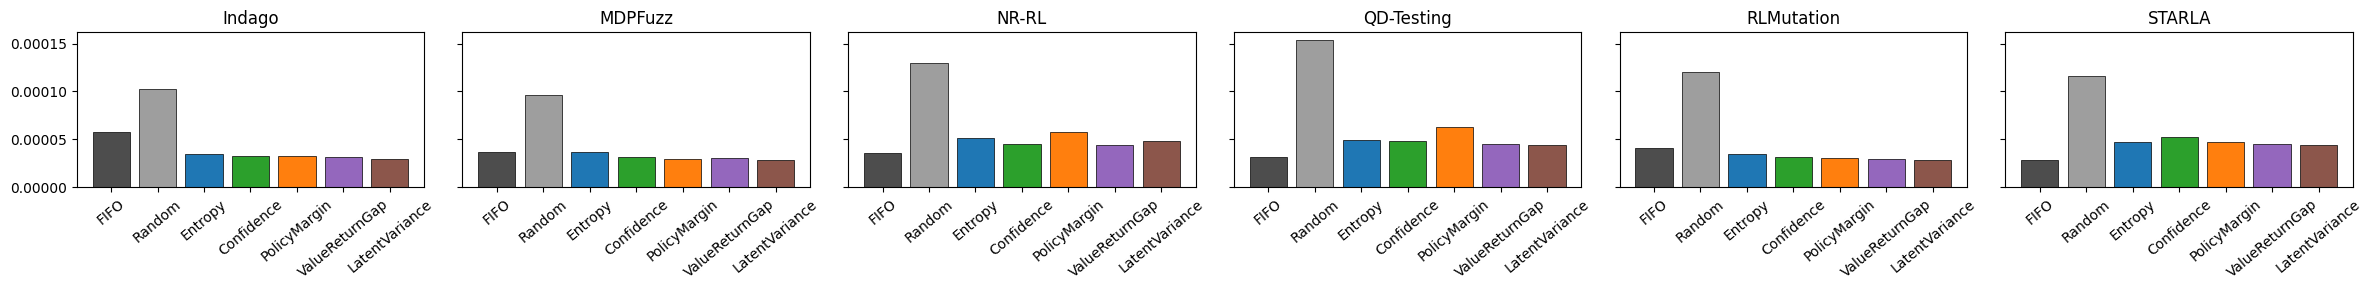


Tables : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/cartpole/tables
Figures: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/cartpole/figs


In [39]:
# =============================================================================
# MAIN
# =============================================================================

def main():

    print("=" * 70)
    print("CARTPOLE TCP REPLICATION")
    print("=" * 70)

    print("\nRunning Phase 1...")

    phase1_results = run_phase1()

    phase1_agg = summarize_phase1(
        phase1_results
    )

    phase1_stats = phase1_statistics(
        phase1_results
    )

    print("\nRunning Phase 2...")

    phase2_results = run_phase2()

    phase2_agg = summarize_phase2(
        phase2_results
    )

    phase2_stats = phase2_statistics(
        phase2_results
    )

    print("\nGenerating plots...")

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase2_apfd(
        phase2_agg
    )

    plot_phase2_overhead(
        phase2_agg
    )

    print(
        f"\nTables : {TABLES_DIR}"
    )

    print(
        f"Figures: {FIGS_DIR}"
    )

    return {
        "phase1_results": phase1_results,
        "phase2_results": phase2_results,
    }


if __name__ == "__main__":

    outputs = main()